In [11]:
import numpy as np
import cupy as cp
import spreadinterp
import libMobility as lm
import functools
from typing import List, Optional
from scipy.sparse.linalg import gmres, LinearOperator
import matplotlib.pyplot as plt


def inverseMdot(
    v: cp.ndarray,
    mdot: callable,
    x0: Optional[cp.ndarray] = None,
    callback: Optional[callable] = None,
    atol: Optional[float] = 1e-3,
    rtol: Optional[float] = 1e-3,
) -> cp.ndarray:
    n = v.size
    op = LinearOperator((n, n), matvec=mdot)
    x, exitCode = gmres(op, v, x0=x0, callback=callback, atol=atol, rtol=rtol, callback_type='legacy')
    if exitCode != 0:
        raise ValueError("gmres did not converge")
    return x


# Vslip is given in m/s with Vrms = 1V and Lambda = 1
# P. Garcia-Sanchez uses Vpp = 6V so Vrms = 6/sqrt(2) V
# They state that Lambda = 0.03 to mach the experimental data
# We will use the same values for our simulations

Lambda = 0.03 
Vrms = (6 / np.sqrt(2))  # Vrms in Volts
um2m = 1e6  # Conversion factor from m/s to um/s
v_slip = cp.load('Vslip.npy')[1:-1,0]*um2m*Vrms**2*Lambda

Lx0 = 160  # um
Lz0 = 190  # um
hydrodynamicRadius = 1 # um This is the radius of the particles determines how many particles are in the simulation

# Kernel of interpolation can be changed, using the one that gives the best results
kernel = spreadinterp.create_kernel('gaussian', width=4*hydrodynamicRadius, cutoff=12*hydrodynamicRadius)
#kernel = spreadinterp.create_kernel('peskin3pt')

#Number of copies of the system in the x direction. [Number of electrodes = 4*n_repeats]
n_repeats = 20

In [12]:
Ny = 12 # Number of cells in the y direction. Determines Ly. Should be greater than the gaussian widhth.

field =  cp.zeros((v_slip.size, Ny, 3), dtype=cp.float32)
field[:,:,0] = cp.tile(v_slip, (Ny, 1)).T
field = cp.ascontiguousarray(cp.array(field[:, :, cp.newaxis, :]))

L = [Lx0, 0.0, Lz0]
L[1] = L[0]*np.shape(field)[1]/np.shape(field)[0]

x = cp.arange(-L[0]/2, L[0]/2, 2*hydrodynamicRadius) + hydrodynamicRadius
y = cp.arange(-L[1]/2, L[1]/2, 2*hydrodynamicRadius) + hydrodynamicRadius

z = cp.arange(0, L[2], 2*hydrodynamicRadius) + hydrodynamicRadius
x_electrode, y_electrode = cp.meshgrid(x, y, indexing='ij')

numberParticles = len(x_electrode.flatten())
particle_positions = cp.zeros((numberParticles, 3), dtype=cp.float32)
particle_positions[:,0] = x_electrode.flatten()
particle_positions[:,1] = y_electrode.flatten()



particle_velocities = spreadinterp.interpolate(
        particle_positions, field, [L[0], L[1], 0.0], kernel=kernel
    )


# Create copies of the system in the x direction
pos_repeated = cp.zeros((n_repeats*numberParticles, 3), dtype=cp.float32)
pos_repeated[:,0] = cp.array([particle_positions[:,0] + (i+0.5)*L[0] for i in range(n_repeats)]).flatten()
pos_repeated[:,1] = cp.tile(particle_positions[:,1], n_repeats)
pos_repeated[:,2] = cp.tile(particle_positions[:,2], n_repeats)

vel_repeated = cp.zeros_like(pos_repeated)
vel_repeated[:,0] = cp.array([particle_velocities[:,0] for i in range(n_repeats)]).flatten()
vel_repeated[:,1] = cp.tile(particle_velocities[:,1], n_repeats)
vel_repeated[:,2] = cp.tile(particle_velocities[:,2], n_repeats)

# Rescale the system to the desired length
L[0] *= n_repeats
pos_repeated[:,0] = pos_repeated[:,0] - L[0]/2 # Center the system at x = 0

# Remove particles with zero velocity in the x direction to accelerate the simulation
pos = pos_repeated[np.abs(vel_repeated[:,0])>0]
vel = vel_repeated[np.abs(vel_repeated[:,0])>0]

# Generate wall particles with zero velocity at x = L[0]/2 and for all y and z
y_wall, z_wall = cp.meshgrid(y, z, indexing='ij')
wall_positions = cp.zeros((len(y_wall.flatten()), 3), dtype=cp.float32)
wall_positions[:,0] = L[0]/2
wall_positions[:,1] = y_wall.flatten()
wall_positions[:,2] = z_wall.flatten()
wall_velocities = cp.zeros_like(wall_positions)

# Combine wall and particle positions and velocities
pos = cp.concatenate((pos, wall_positions), axis=0)
vel = cp.concatenate((vel, wall_velocities), axis=0)

In [13]:
# Initialize the solver. Peridicity should not be changed.
periodicityXY = 'periodic'
periodicityZ = 'two_walls'

wallHeight = -2*hydrodynamicRadius
solver = lm.DPStokes(periodicityX=periodicityXY, periodicityY=periodicityXY, periodicityZ=periodicityZ)
solver.setParameters(Lx=L[0],Ly=L[1], zmin=wallHeight, zmax=L[2]+2*hydrodynamicRadius)
solver.initialize(
        viscosity=0.01/(6*np.pi),
        hydrodynamicRadius=hydrodynamicRadius,
        includeAngular=False,
    )

[WARNING] [DPStokes] Domains with Lx=Ly are largely untested


In [14]:
# GMRES algorithm to solve the inverse problem

solver.setPositions(pos.get())
def mdot(solver, vector):
    mf, _ = solver.Mdot(forces=vector)
    return mf

mdot_partial = functools.partial(mdot, solver)
forces = inverseMdot(
    vel.get().flatten(),
    mdot_partial,
    #callback=print_tolerance_callback,
    rtol=1e-3,
    atol=0
)
forces = forces.reshape(-1,3)

In [15]:
# Sampling the velocities on the fluid domain

# Choose the number of tracers and their positions
Lx_max = Lx0*2 # (um) len where you want to sample the velocities
N_trac = np.array([1000,1,0]) # Nz will be determined by the length of the domain so particles are on a square lattice
N_trac[2] = int(N_trac[0]/Lx_max*L[2])

x = cp.linspace(-Lx_max/2, Lx_max/2, N_trac[0])
y = cp.array([0])
z = cp.linspace(0, L[2], N_trac[2])
xx_trac ,yy_trac ,zz_trac = cp.meshgrid(x,y,z,indexing='ij')
tracer_pos = cp.zeros([np.prod(N_trac),3])
tracer_pos[:,0] = xx_trac.flatten()
tracer_pos[:,1] = yy_trac.flatten()
tracer_pos[:,2] = zz_trac.flatten()
tracer_forces = tracer_pos*0
total_pos = cp.concatenate([pos,tracer_pos],axis=0)
total_force = cp.concatenate([cp.array(forces),tracer_forces],axis=0)

solver.setPositions(total_pos)
mf, _ = solver.Mdot(forces=total_force)
solver.clean()

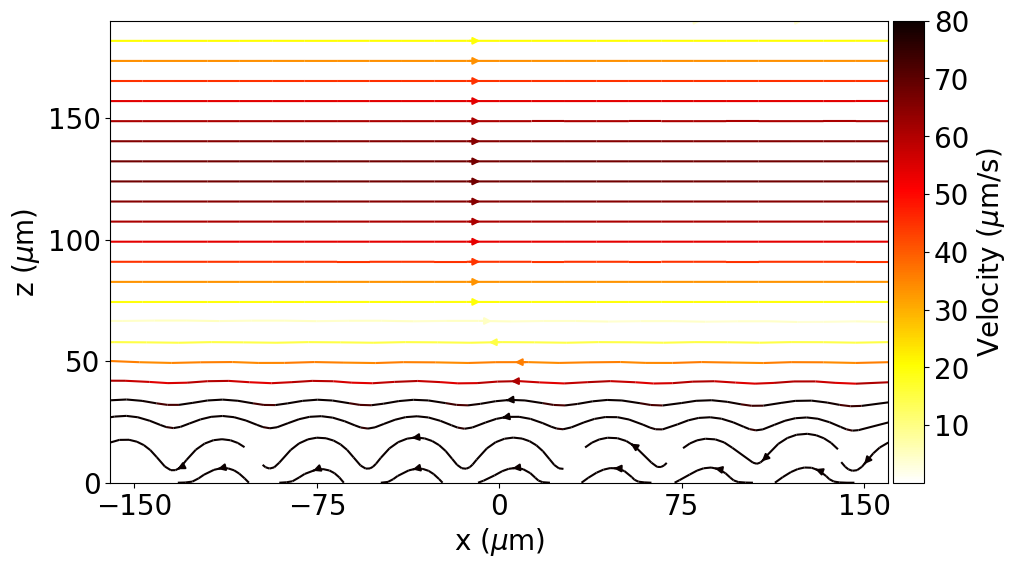

In [16]:
# Plotting the streamlines
grid_mf = np.reshape(mf[len(pos):,:], (N_trac[0], N_trac[1], N_trac[2], 3))
u = grid_mf[:,0,:,0].get().T
v = grid_mf[:,0,:,2].get().T
color = np.sqrt(u*u+v*v)
color[color > 80] = 80  # Set a maximum
fig, ax = plt.subplots(figsize=(12, 6))
ax.streamplot(xx_trac[:,0,:].get().T, zz_trac[:,0,:].get().T, u, v, density=0.8, broken_streamlines=True, color=color ,cmap='hot_r')


from mpl_toolkits.axes_grid1 import make_axes_locatable
fontsize = 20
ax.set_ylim((0, 190))
ax.set_aspect('equal')
ax.set_ylabel(r'z ($\mu$m)',fontsize=fontsize)
ax.set_xlabel(r'x ($\mu$m)',fontsize=fontsize)
ax.set_yticks([0, 50, 100, 150])
ax.set_xticks([-150, -75, 0, 75, 150])
ax.tick_params(labelsize=fontsize)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="4%",pad=0.05)
cbar = fig.colorbar(ax.collections[0],cax=cax, shrink=0.95)
cbar.ax.tick_params(labelsize=fontsize)
cbar.ax.set_ylabel(r'Velocity ($\mu$m/s)', fontsize=fontsize)
# plt.savefig("transientStreamplot.svg", format='svg') # Uncomment to save the figure
plt.show()

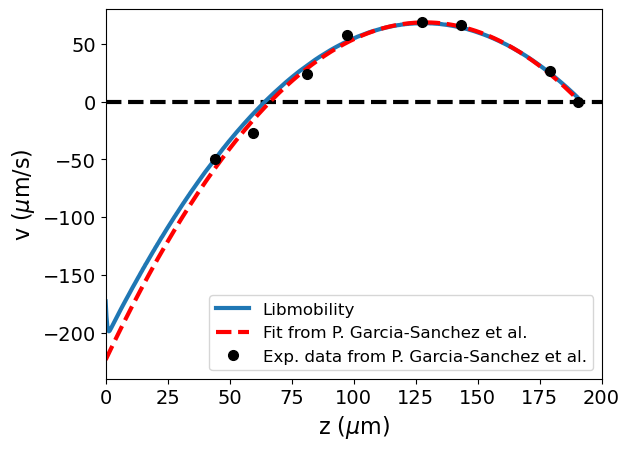

In [17]:
# Plotting the velocity profile

z = np.linspace(0,L[2],np.shape(u)[0])
z_min = 0 # Minimum z value to consider in the profile
mask = z>z_min
mask2 = ((total_pos[len(pos):,2].get())>z_min)

# Experimental data from P. Garcia-Sanchez et al.
x_exp = [44.21052631578947, 59.57894736842105, 81.26315789473684, 97.26315789473684, 127.57894736842104, 143.1578947368421, 179.15789473684208, 190.52631578947367]
y_exp = [-49.855072463768124, -27.08827404479578, 23.504611330698253, 57.65480895915675, 68.61660079051381, 66.08695652173913, 26.034255599473, -0.5270092226614054]

u_mean = np.mean(u[:,:],axis=1)

plt.axhline(0, color='k', linestyle='--', linewidth=3)
plt.plot(z, u_mean, '-', label='Libmobility',linewidth=3)
plt.plot(z, -223.64 + 4.5377*z - 0.01762*z*z, 'r--', linewidth=3,label='Fit from P. Garcia-Sanchez et al.')

plt.plot(x_exp, y_exp, 'ko', label='Exp. data from P. Garcia-Sanchez et al.', markersize=7)
plt.xlim([0, 200])
plt.ylim([-240, 80])
plt.xlabel(r'z ($\mu$m)', fontsize=16)
plt.ylabel(r'v ($\mu$m/s)', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=12)
# plt.savefig("velocityProfile.svg", format='svg') # Uncomment to save the figure
plt.show()